<a href="https://colab.research.google.com/github/laboratoriodecodigos/Colab-Python/blob/main/Ejemplo_Control_Difuso.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 17.5 MB/s eta 0:00:00


In [3]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

In [5]:
# CREAR VARIABLES DIFUSAS

# Variable de entrada: Temperatura
temperatura = ctrl.Antecedent(np.arange(0, 41, 1), 'temperatura')

# Variable de salida: Velocidad
velocidad = ctrl.Consequent(np.arange(0, 101, 1), 'velocidad')

In [12]:
# FUZZIFICACIÓN
# DEFINICIÓN DE FUNCIONES DE MEMBRESÍA

# TEMPERATURA


# Frío
temperatura['frio'] = fuzz.trimf(
    temperatura.universe,
    [0, 0, 20]
)

# Tibio
temperatura['tibio'] = fuzz.trimf(
    temperatura.universe,
    [10, 20, 30]
)

# Caliente
temperatura['caliente'] = fuzz.trimf(
    temperatura.universe,
    [20, 40, 40]
)


# VELOCIDAD


# Baja
velocidad['baja'] = fuzz.trimf(
    velocidad.universe,
    [0, 0, 50]
)

# Media
velocidad['media'] = fuzz.trimf(
    velocidad.universe,
    [25, 50, 75]
)

# Alta
velocidad['alta'] = fuzz.trimf(
    velocidad.universe,
    [50, 100, 100]
)

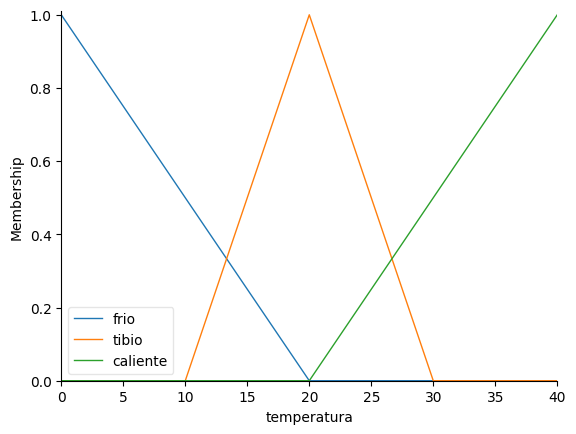

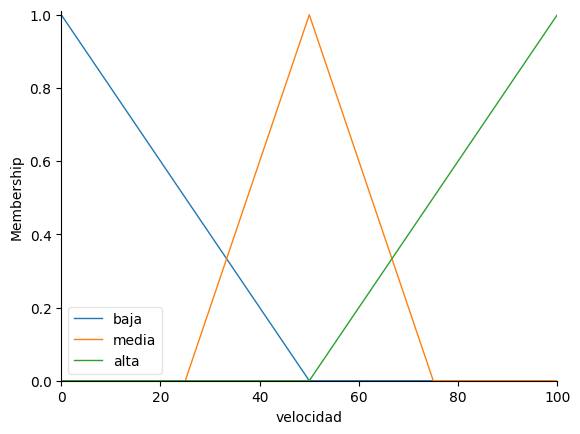

In [7]:
# MOSTRAR FUNCIONES DE MEMBRESÍA

temperatura.view()
plt.show()

velocidad.view()
plt.show()

In [8]:
# REGLAS DIFUSAS

# Regla 1
# SI temperatura es fría
# ENTONCES velocidad es baja

regla1 = ctrl.Rule(
    temperatura['frio'],
    velocidad['baja']
)

# Regla 2
# SI temperatura es tibia
# ENTONCES velocidad es media

regla2 = ctrl.Rule(
    temperatura['tibio'],
    velocidad['media']
)

# Regla 3
# SI temperatura es caliente
# ENTONCES velocidad es alta

regla3 = ctrl.Rule(
    temperatura['caliente'],
    velocidad['alta']
)

In [9]:
# CREAR SISTEMA DE CONTROL

sistema_control = ctrl.ControlSystem(
    [regla1, regla2, regla3]
)

# Simulador
simulador = ctrl.ControlSystemSimulation(
    sistema_control
)

RESULTADO DEL SISTEMA DIFUSO
Temperatura de entrada: 28 °C
Velocidad calculada: 69.81%


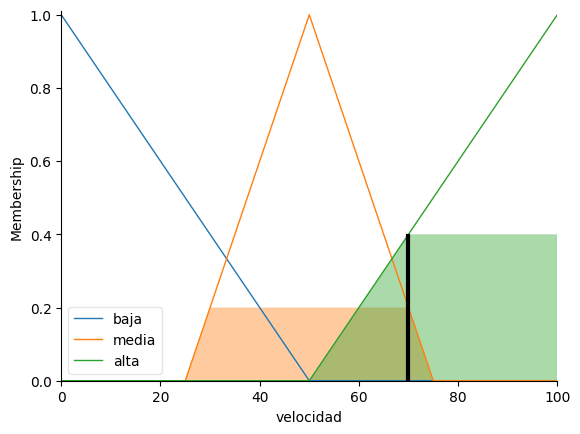

In [11]:
# INGRESAR DATOS AL SISTEMA

# Temperatura actual
simulador.input['temperatura'] = 28


# INFERENCIA DIFUSA


# Ejecutar sistema
simulador.compute()


# DESFUZZIFICACIÓN

# Resultado numérico final
resultado = simulador.output['velocidad']


print("RESULTADO DEL SISTEMA DIFUSO")

print(f"Temperatura de entrada: 28 °C")
print(f"Velocidad calculada: {resultado:.2f}%")

# VISUALIZAR RESULTADO FINAL


velocidad.view(sim=simulador)
plt.show()